In [2]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy
import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats




sys.path.append('../..')
import plot_settings
import importlib
import multi_exp_log

from IPython.display import display, Math
from pysr import PySRRegressor, TemplateExpressionSpec
# import mean
from pysr import jl
jl.seval("using Statistics")

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(multi_exp_log)

import_reload()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


# Importing data

In [3]:
DT = 1
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [6]:


def read_data(file_name):
    df = pd.read_csv(
        f"../Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    # cols = u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
    #df.columns = ['u_par','C','t','V','I','F','u','Ue','eta','trajectory','dV','dF','soc']
    # Sort by time within each batch
    return df


path = f'2_merged_data'

data = read_data(path)
display(data.head())


,u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
0,0.4,2.2,0.0,4.239833,10.952074,0.030566,-0.057493,4.324996,-0.085164,0,-0.027881,-0.000470,0.999389
1,0.4,2.2,1.0,4.211952,10.952074,0.030096,-0.057493,4.323139,-0.111187,0,-0.016738,-0.000471,0.998778
2,0.4,2.2,2.0,4.195213,10.952074,0.029624,-0.057493,4.321278,-0.126065,0,-0.011734,-0.000471,0.998167
3,0.4,2.2,3.0,4.183479,10.952074,0.029153,-0.057493,4.319417,-0.135938,0,-0.006706,-0.000471,0.997556
4,0.4,2.2,4.0,4.176773,10.952074,0.028682,-0.057493,4.317557,-0.140783,0,-0.005763,-0.000471,0.996944


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

## The sampled terrain

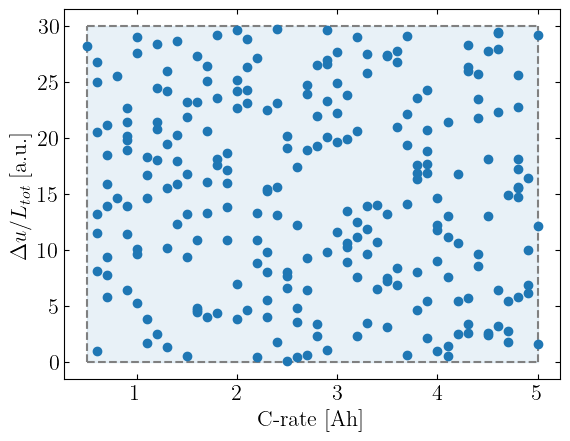

In [7]:
u_C_pairs = data.loc[data['t'] == 0, ['u_par', 'C']]
plt.xlabel('C-rate [Ah]')
plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
plt.vlines(0.5,0,30, color='gray', linestyle='--')
plt.vlines(5,0,30, color='gray', linestyle='--')
plt.hlines(0,0.5,5, color='gray', linestyle='--')
plt.hlines(30,0.5,5, color='gray', linestyle='--')
plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
plt.plot(u_C_pairs['C'], u_C_pairs['u_par'], 'o')

# Plotting data

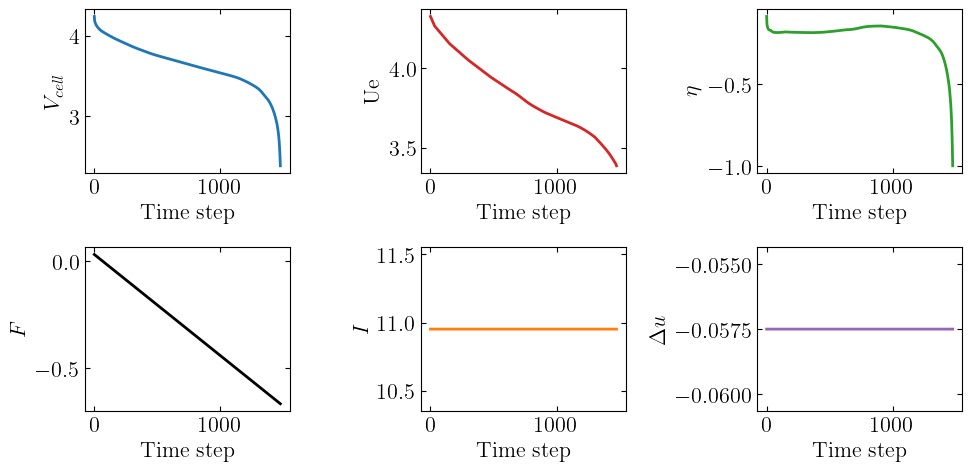

In [8]:

plot_idx = data['trajectory'] == 0
f, ax = plt.subplots(2, 3, figsize=(10, 5))
ax[0,0].plot(data['V'][plot_idx], '-', color = colors[0], lw = 2)
ax[0,0].set_xlabel('Time step')
ax[0,0].set_ylabel('$V_{cell}$')
ax[0,1].plot(data['Ue'][plot_idx], '-', color = colors[1], lw = 2)
ax[0,1].set_xlabel('Time step')
ax[0,1].set_ylabel('Ue')
ax[0,2].plot(data['eta'][plot_idx], '-', color = colors[2], lw = 2)
ax[0,2].set_xlabel('Time step')
ax[0,2].set_ylabel(r'$\eta$')
ax[1,0].plot(data['F'][plot_idx], lw = 2,color = colors[3])
ax[1,0].set_xlabel('Time step')
ax[1,0].set_ylabel(r'$F$')
ax[1,1].plot(data['I'][plot_idx], lw = 2,color = colors[4])
ax[1,1].set_xlabel('Time step')
ax[1,1].set_ylabel(r'$I$')
ax[1,2].plot(data['u'][plot_idx], lw = 2,color = colors[5])
ax[1,2].set_xlabel('Time step')
ax[1,2].set_ylabel(r'$\Delta u$')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Estimated R0 vs SoC')

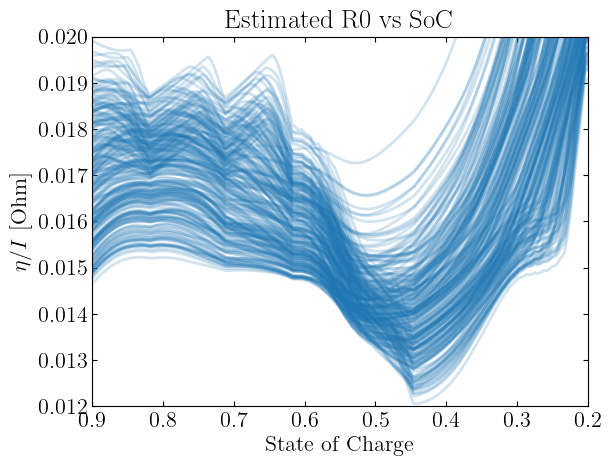

In [9]:

for plot_idx in np.unique(data['trajectory'].values):
    plt.plot(data['soc'][data['trajectory'] == plot_idx], -data['eta'][data['trajectory'] == plot_idx] / data['I'][data['trajectory'] == plot_idx], '-', color = colors[0], lw = 2,alpha=0.2)
plt.xlim(0.2,0.9)
plt.ylim(0.012,.02)
plt.gca().invert_xaxis()
plt.xlabel('State of Charge')
plt.ylabel(r'$\eta / I$ [Ohm]')
plt.title('Estimated R0 vs SoC')

In [33]:
u = data.groupby('trajectory')['u'].first().values
I = data.groupby('trajectory')['I'].first().values
eta_frac_list = []; I_list = []; soc_max_list = []
for traj in data['trajectory'].unique():
    soc_traj = data['soc'][(data['trajectory'] == traj)].max()
    soc_max_list.append(soc_traj)
    #print(f'Trajectory {traj}: SoC = {soc_traj:.2f}')
    eta_frac = -data['eta'][(data['trajectory'] == traj) & (data['soc'] == soc_traj)].values[0] / data['I'][(data['trajectory'] == traj)].max() 
    #print(eta_frac)
    I_list.append(data['I'][(data['trajectory'] == traj)].max())
    #/ data['I'][(data['trajectory'] == traj)].max()
    #idx = (eta_frac).abs().idxmin()
    eta_frac_list.append(eta_frac)
    print(f'Trajectory {traj}: Max |eta/I| = {eta_frac:.5f} Ohm at SoC = {soc_traj:.2f}')


R0_est = np.asarray(eta_frac_list)


Trajectory 0: Max |eta/I| = 0.00778 Ohm at SoC = 1.00
Trajectory 1: Max |eta/I| = 0.00754 Ohm at SoC = 1.00
Trajectory 2: Max |eta/I| = 0.00829 Ohm at SoC = 1.00
Trajectory 3: Max |eta/I| = 0.00861 Ohm at SoC = 1.00
Trajectory 4: Max |eta/I| = 0.00767 Ohm at SoC = 1.00
Trajectory 5: Max |eta/I| = 0.00820 Ohm at SoC = 1.00
Trajectory 6: Max |eta/I| = 0.00694 Ohm at SoC = 1.00
Trajectory 7: Max |eta/I| = 0.00797 Ohm at SoC = 1.00
Trajectory 8: Max |eta/I| = 0.00798 Ohm at SoC = 1.00
Trajectory 9: Max |eta/I| = 0.00771 Ohm at SoC = 1.00
Trajectory 10: Max |eta/I| = 0.00766 Ohm at SoC = 1.00
Trajectory 11: Max |eta/I| = 0.00742 Ohm at SoC = 1.00
Trajectory 12: Max |eta/I| = 0.00815 Ohm at SoC = 1.00
Trajectory 13: Max |eta/I| = 0.00849 Ohm at SoC = 1.00
Trajectory 14: Max |eta/I| = 0.00847 Ohm at SoC = 1.00
Trajectory 15: Max |eta/I| = 0.00817 Ohm at SoC = 1.00
Trajectory 16: Max |eta/I| = 0.00823 Ohm at SoC = 1.00
Trajectory 17: Max |eta/I| = 0.00772 Ohm at SoC = 1.00
Trajectory 18: Max |

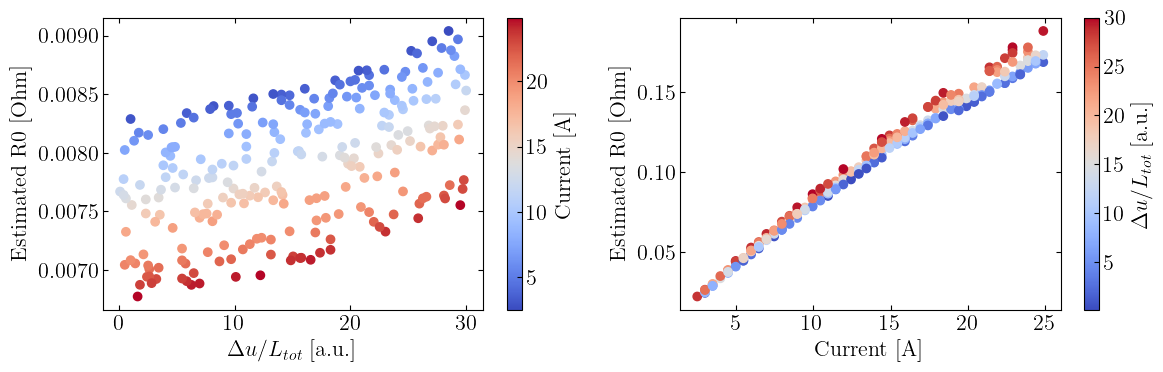

In [35]:
f, ax = plt.subplots(1,2,figsize=(12,4))

sc0 = ax[0].scatter(30 * u/u.min(), R0_est, c=I_list, cmap='coolwarm')
ax[0].set_xlabel(r'$\Delta u / L_{tot}$ [a.u.]')
ax[0].set_ylabel('Estimated R0 [Ohm]')
cbar0 = plt.colorbar(sc0, ax=ax[0])
cbar0.set_label('Current [A]')

sc1 = ax[1].scatter(I, R0_est*I_list, c=30 * u/u.min(), cmap='coolwarm')
ax[1].set_xlabel('Current [A]')
ax[1].set_ylabel('Estimated R0 [Ohm]')
cbar1 = plt.colorbar(sc1, ax=ax[1])
cbar1.set_label(r'$\Delta u / L_{tot}$ [a.u.]')

plt.tight_layout()

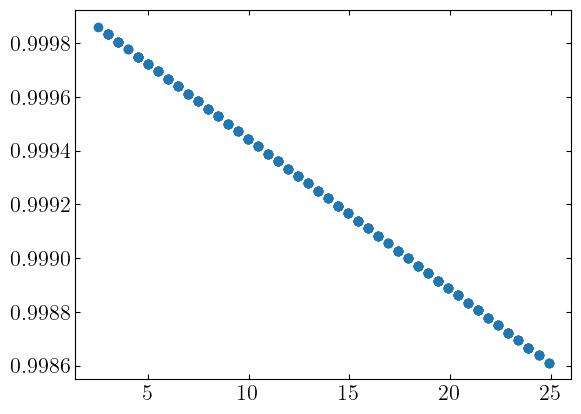

In [34]:
plt.plot(I_list, soc_max_list, 'o')

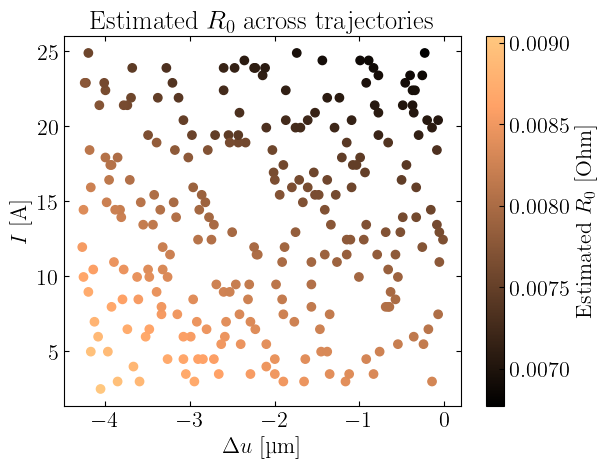

In [ ]:
#R0_est = data['eta'][(data['soc'] < 0.8) & (data['soc'] > 0.3)].values / data['I'][(data['soc'] < 0.8) & (data['soc'] > 0.3)].values

plt.scatter(u,I, c = R0_est, cmap = 'copper')
plt.colorbar(label = r'Estimated $R_0$ [Ohm]')
plt.xlabel(r'$\Delta u$ [µm]')
plt.ylabel(r'$I$ [A]')
plt.title('Estimated $R_0$ across trajectories')
plt.show()

In [10]:
X_data = np.vstack((u,I)).T
Y_data = R0_est

print(f'X_data shape: {X_data.shape}')
print(f'Y_data shape: {Y_data.shape}')

X_data shape: (248, 2)
Y_data shape: (248, 1)


In [11]:
model = PySRRegressor(
    model_selection="score",
    niterations=250,
    binary_operators=[
        "+", "*", '-','/'
    ],
    unary_operators=['sqrt','square', 'cube'],
    elementwise_loss="loss(x, y) = (x - y)^2",
    populations=20,
    verbosity=0
)


In [12]:
model.fit(X_data, Y_data)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


,model_selection,'score'
,binary_operators,"['+', '*', ...]"
,unary_operators,"['sqrt', 'square', ...]"
,expression_spec,None
,niterations,250
,populations,20
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


Text(0.5, 1.0, 'Model Complexity vs Loss')

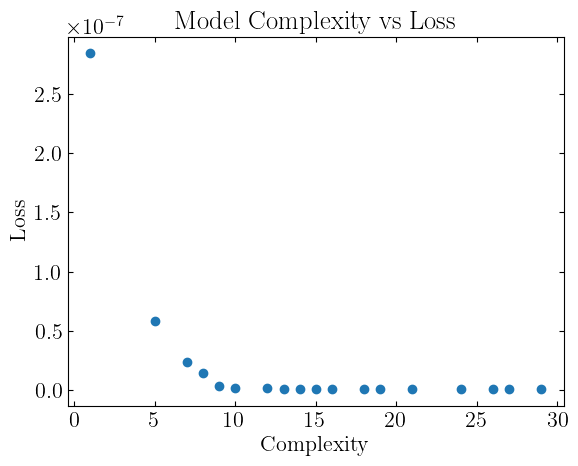

In [13]:
df_model = model.equations_

plt.scatter(df_model['complexity'], df_model['loss'])
plt.xlabel('Complexity')
plt.ylabel('Loss')
plt.title('Model Complexity vs Loss')

In [14]:
model_index = None
display(Math(f'\\LARGE {model.latex(model_index)}'))
print(f'Best model in symbolic form: {model.sympy()}')

<IPython.core.display.Math object>

Best model in symbolic form: x0*(-0.0001887521) - 7.049519e-5*x1 + 0.008446693


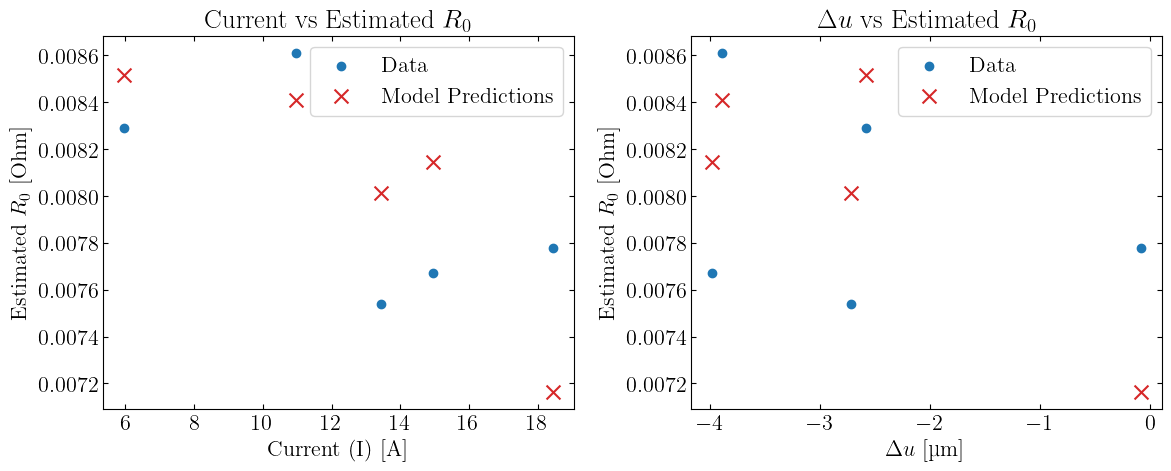

In [162]:
rand_samples = np.random.choice(len(u),size=5, replace=False)
I_test = I[rand_samples]
u_test = u[rand_samples]
R0_test = R0_est[:5]
R0_pred = model.predict(np.vstack((u_test, I_test)).T)

f, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(I_test, R0_test, label='Data', color=colors[0])
ax[0].scatter(I_test, R0_pred, label='Model Predictions', color=colors[1], marker='x', s=100)
ax[0].set_xlabel('Current (I) [A]')
ax[0].set_ylabel('Estimated $R_0$ [Ohm]')
ax[0].set_title('Current vs Estimated $R_0$')
ax[0].legend()
ax[1].scatter(u_test, R0_test, label='Data', color=colors[0])
ax[1].scatter(u_test, R0_pred, label='Model Predictions', color=colors[1], marker='x', s=100)
ax[1].set_xlabel(r'$\Delta u$ [µm]')
ax[1].set_ylabel('Estimated $R_0$ [Ohm]')
ax[1].set_title(r'$\Delta u$ vs Estimated $R_0$')
ax[1].legend()
plt.tight_layout()
plt.show()

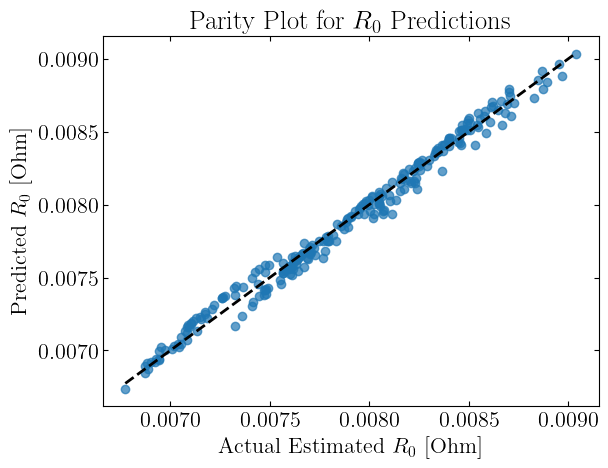

In [33]:
# Parity plot
R0_pred = model.predict(X_data)
plt.scatter(R0_est, R0_pred, color=colors[0],alpha = 0.7)
plt.plot([R0_est.min(), R0_est.max()], [R0_est.min(), R0_est.max()], 'k--', lw=2)
plt.xlabel('Actual Estimated $R_0$ [Ohm]')
plt.ylabel('Predicted $R_0$ [Ohm]')
plt.title('Parity Plot for $R_0$ Predictions')
plt.show()

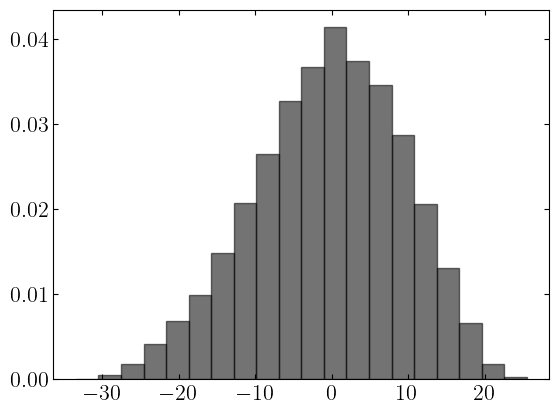

In [164]:
plt.hist(100 * (1  - R0_pred / R0_est).ravel(), bins=20, color=colors[3], edgecolor='k', alpha=0.55, density=True)
plt.show()

Text(0.5, 1.0, 'Estimated R0 vs SoC')

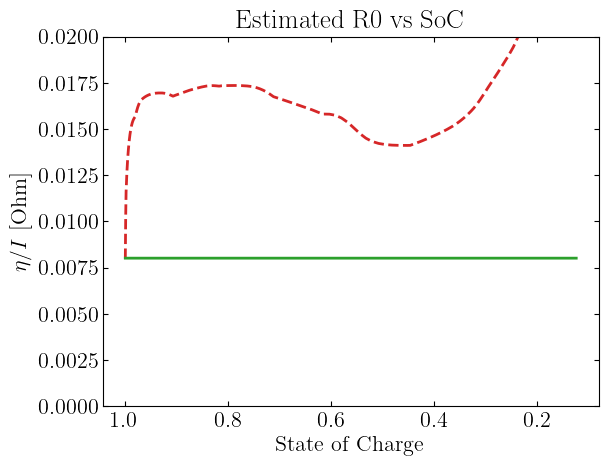

In [32]:
plot_idx = 8

plt.plot(data['soc'][data['trajectory'] == plot_idx], -data['eta'][data['trajectory'] == plot_idx] / data['I'][data['trajectory'] == plot_idx], '--', color = colors[1], lw = 2,alpha=1)
plt.plot(data['soc'][data['trajectory'] == plot_idx], model.predict(np.vstack((data['u'][data['trajectory'] == plot_idx], data['I'][data['trajectory'] == plot_idx])).T), '-', color = colors[2], lw = 2,alpha=1)

plt.ylim(0.0,.02)
plt.gca().invert_xaxis()
plt.xlabel('State of Charge')
plt.ylabel(r'$\eta / I$ [Ohm]')
plt.title('Estimated R0 vs SoC')

Text(0.5, 1.0, 'Estimated $R_0$ across the input space')

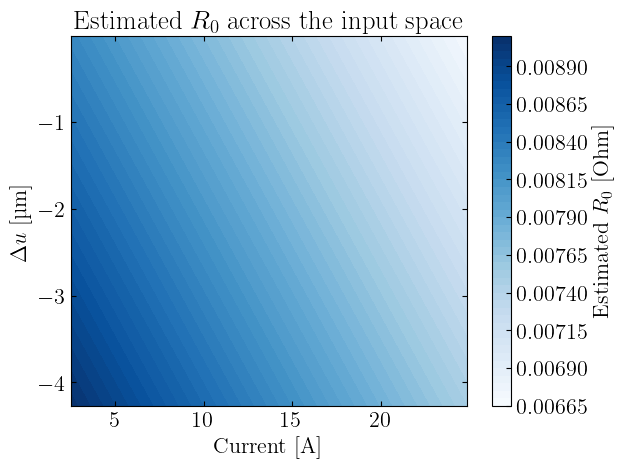

In [42]:
u_grid, I_grid = plot_settings.grid_gen([np.min(u), np.max(u)], [np.min(I), np.max(I)], [100,100])

R0_grid = model.predict(np.vstack((u_grid.ravel(), I_grid.ravel())).T).reshape(u_grid.shape)

plt.contourf(I_grid, u_grid, R0_grid, levels=50, cmap='Blues')
plt.colorbar(label = 'Estimated $R_0$ [Ohm]')
plt.xlabel('Current [A]')
plt.ylabel(r'$\Delta u$ [µm]')
plt.title('Estimated $R_0$ across the input space')



{4.1, 4.0, 4.9, 4.6, 4.7, 4.3, 4.5, 5.0, 4.7, 3.6, 3.7, 3.5, 3.5, 4.9, 4.6, 4.0, 4.1, 4.3, 4.7, 3.9, 3.6, 4.2, 4.8, 4.4, 4.5, 3.7, 4.4, 4.6, 3.8, 3.8, 4.9, 4.8, 4.0, 4.4, 4.7, 4.9, 3.8, 4.3, 4.0, 4.1, 3.7, 5.0, 3.7, 3.6, 4.0, 4.2, 3.8, 3.7, 4.8, 4.4, 4.2, 4.6, 3.9, 3.6, 4.3, 3.9, 4.1, 3.5, 4.5, 4.7, 4.5, 4.8, 4.7, 4.4, 3.8, 4.2, 4.2, 4.9, 3.9, 4.3}


{2.8, 3.3, 22.8, 15.9, 3.8, 2.2, 1.2, 18.8, 1.3, 28.9, 17.8, 29.8, 5.9, 17.4, 26.2, 26.9, 18.9, 23.4, 12.7, 19.5, 10.7, 7.6, 6.1, 13.8, 15.7, 16.5, 15.2, 28.4, 24.6, 23.9, 13.0, 4.5, 0.8, 11.7, 27.8, 29.4, 7.0, 12.0, 27.1, 13.4, 22.1, 24.3, 14.3, 26.1, 7.7, 22.5, 20.8, 4.8, 4.0, 20.5, 25.2, 0.0, 11.4, 1.9, 10.1, 21.6, 5.2, 18.2, 25.4, 28.0, 8.6, 9.8, 16.9, 21.1, 14.9, 6.6, 8.2, 20.0, 9.1, 11.1}

In [43]:
c_list = [4.1, 4.0, 4.9, 4.6, 4.7, 4.3, 4.5, 5.0, 4.7, 3.6, 3.7, 3.5, 3.5, 4.9, 4.6, 4.0, 4.1, 4.3, 4.7, 3.9, 3.6, 4.2, 4.8, 4.4, 4.5, 3.7, 4.4, 4.6, 3.8, 3.8, 4.9, 4.8, 4.0, 4.4, 4.7, 4.9, 3.8, 4.3, 4.0, 4.1, 3.7, 5.0, 3.7, 3.6, 4.0, 4.2, 3.8, 3.7, 4.8, 4.4, 4.2, 4.6, 3.9, 3.6, 4.3, 3.9, 4.1, 3.5, 4.5, 4.7, 4.5, 4.8, 4.7, 4.4, 3.8, 4.2, 4.2, 4.9, 3.9, 4.3]
u_list = [2.8, 3.3, 22.8, 15.9, 3.8, 2.2, 1.2, 18.8, 1.3, 28.9, 17.8, 29.8, 5.9, 17.4, 26.2, 26.9, 18.9, 23.4, 12.7, 19.5, 10.7, 7.6, 6.1, 13.8, 15.7, 16.5, 15.2, 28.4, 24.6, 23.9, 13.0, 4.5, 0.8, 11.7, 27.8, 29.4, 7.0, 12.0, 27.1, 13.4, 22.1, 24.3, 14.3, 26.1, 7.7, 22.5, 20.8, 4.8, 4.0, 20.5, 25.2, 0.0, 11.4, 1.9, 10.1, 21.6, 5.2, 18.2, 25.4, 28.0, 8.6, 9.8, 16.9, 21.1, 14.9, 6.6, 8.2, 20.0, 9.1, 11.1]

print(len(c_list), len(u_list))

70 70
